# Conformal Prediction – Exercises

This notebook walks through conformal prediction, using a small synthetic dataset.

**Contents**
1. Setup & Dataset
2. Baseline Linear Regression
3. Naive Conformal Prediction (all data)
4. Split Conformal Prediction (SCP)
5. Quantile Regression SCP
6. Weighted SCP
7. Full Conformal Prediction

## 1. Setup & Dataset

Import libraries, create the initial 8-point dataset, and generate 10 new test points.

Dataset shape: (8, 2)
Dataset:
 [[5 0]
 [3 3]
 [7 9]
 [3 5]
 [2 4]
 [7 6]
 [8 8]
 [1 6]]


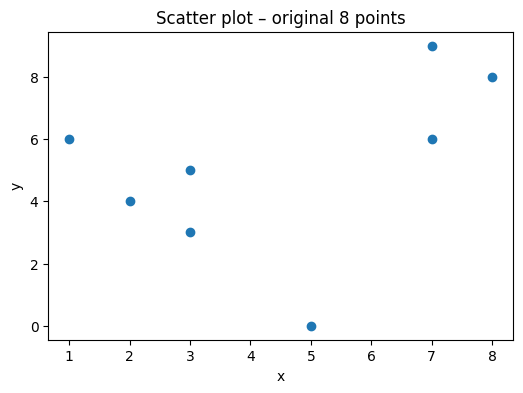


10 new points:
 [[6 3]
 [7 4]
 [6 9]
 [2 6]
 [7 4]
 [3 7]
 [7 2]
 [5 4]
 [1 7]
 [5 1]]


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, QuantileRegressor

# ── Original 8-point dataset
np.random.seed(0)
dataset = np.random.randint(10, size=(8, 2))
print("Dataset shape:", dataset.shape)
print("Dataset:\n", dataset)

X = dataset[:, 0].reshape(-1, 1)
Y = dataset[:, 1].reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X, Y)
plt.title("Scatter plot – original 8 points")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# ── 10 new test points 
np.random.seed(42)
new_points = np.random.randint(10, size=(10, 2))
print("\n10 new points:\n", new_points)

## 2. Baseline Linear Regression

Fit a linear regression on the 8-point dataset and visualise the fit together with residuals.

Coefficient : [[0.46875]]
Intercept   : [3.015625]


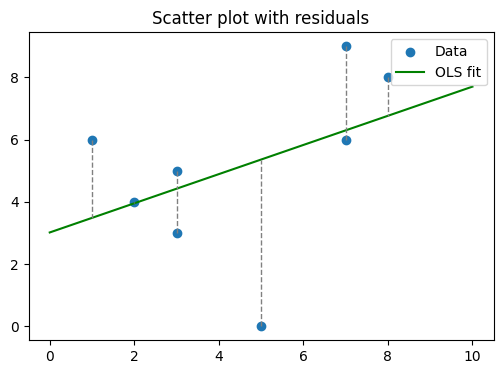

In [2]:
model = LinearRegression().fit(X, Y)
print("Coefficient :", model.coef_)
print("Intercept   :", model.intercept_)

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.intercept_[0] + x_line * model.coef_[0]
y_pred = model.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X, Y, label="Data")
plt.plot(x_line, y_line, color="green", label="OLS fit")
for i in range(len(X)):
    plt.plot([X[i][0], X[i][0]], [Y[i][0], y_pred[i][0]],
             linestyle="--", color="grey", linewidth=1)
plt.title("Scatter plot with residuals")
plt.legend()
plt.show()

## 3. Naive Conformal Prediction (all data)

Compute conformity scores on the full dataset (no train/calibration split) and draw the symmetric prediction band.

**α = 0.25** → we keep 75 % of the residuals.

Sorted absolute residuals: [0.046875 0.296875 0.578125 1.234375 1.421875 2.515625 2.703125 5.359375]
Quantile index: 6
Quantile (half-width)    : 2.515625


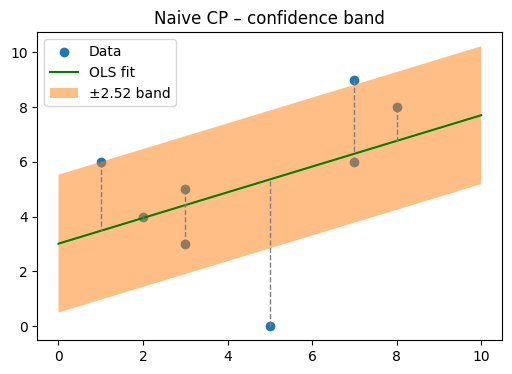

In [ ]:
alpha = 0.25

Residuals      = (Y - y_pred).flatten()
abs_residuals  = np.abs(Residuals)
sorted_residuals = np.sort(abs_residuals)

quantile_index = math.ceil((1 - alpha) * len(sorted_residuals))
quantile = sorted_residuals[quantile_index - 1]

print("Sorted absolute residuals:", sorted_residuals)
print("Quantile index:", quantile_index)
print("Quantile (half-width)    :", quantile)

# ── Visualise
plt.figure(figsize=(6, 4))
plt.scatter(X, Y, label="Data")
plt.plot(x_line, y_line, color="green", label="OLS fit")
for i in range(len(X)):
    plt.plot([X[i][0], X[i][0]], [Y[i][0], y_pred[i][0]],
             linestyle="--", color="grey", linewidth=1)
plt.fill_between(x_line.flatten(),
                 y_line.flatten() + quantile,
                 y_line.flatten() - quantile,
                 alpha=0.5, label=f"±{quantile:.2f} band")
plt.title("Naive CP – confidence band")
plt.legend()
plt.show()

### Add 10 new points to the plot

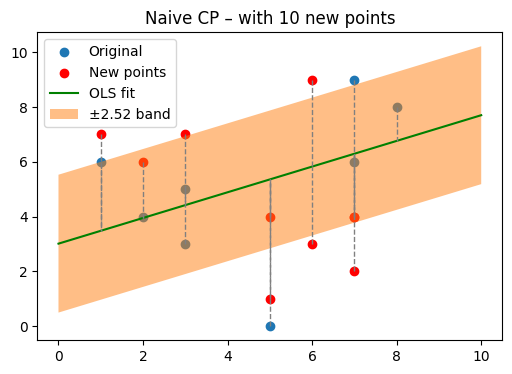

In [4]:
new_X = np.append(X.flatten(), new_points[:, 0])
new_Y = np.append(Y.flatten(), new_points[:, 1])
new_y_pred_all = model.predict(new_X.reshape(-1, 1)).flatten()

plt.figure(figsize=(6, 4))
plt.scatter(X.flatten(), Y.flatten(), label="Original")
plt.scatter(new_points[:, 0], new_points[:, 1], color="red", label="New points")
plt.plot(x_line.flatten(), y_line.flatten(), color="green", label="OLS fit")
for i in range(len(new_X)):
    plt.plot([new_X[i], new_X[i]], [new_Y[i], new_y_pred_all[i]],
             linestyle="--", color="grey", linewidth=1)
plt.fill_between(x_line.flatten(),
                 y_line.flatten() + quantile,
                 y_line.flatten() - quantile,
                 alpha=0.5, label=f"±{quantile:.2f} band")
plt.title("Naive CP – with 10 new points")
plt.legend()
plt.show()

## 4. Split Conformal Prediction (Mean SCP)

Split the combined 18-point dataset into **train / calibration / test** (6 each), fit a fresh linear model on the training set, compute the quantile on the calibration residuals, and plot.

Train:
 [[3 3]
 [8 8]
 [6 3]
 [6 9]
 [7 2]
 [2 4]]
Calibration:
 [[7 9]
 [1 7]
 [5 1]
 [7 4]
 [1 6]
 [3 7]]
Test:
 [[2 6]
 [3 5]
 [5 0]
 [7 6]
 [5 4]
 [7 4]]

Intercept: [2.42682927]
Coefficient: [[0.45121951]]

Sorted calibration residuals: [1.58536585 3.12195122 3.2195122  3.41463415 3.68292683 4.12195122]
Quantile index : 6
Quantile (half-width): 4.121951219512194


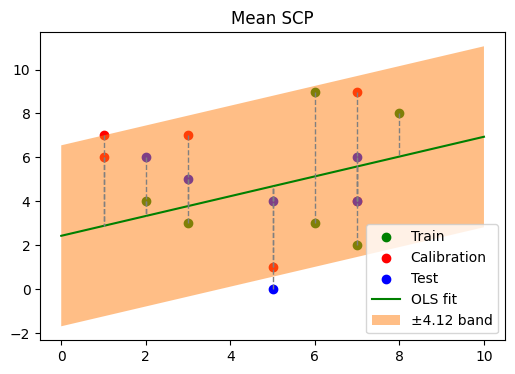

In [ ]:
np.random.seed(0)

full_dataset = np.vstack((dataset, new_points))
np.random.shuffle(full_dataset)
train, calibration, test = np.split(full_dataset, 3)

print("Train:\n",       train)
print("Calibration:\n", calibration)
print("Test:\n",        test)

# ── Fit on train
mean_model = LinearRegression().fit(
    train[:, 0].reshape(-1, 1),
    train[:, 1].reshape(-1, 1)
)
print("\nIntercept:", mean_model.intercept_)
print("Coefficient:", mean_model.coef_)

y_fit_line = mean_model.intercept_[0] + x_line * mean_model.coef_[0]

# ── Calibration predictions
y_cal  = mean_model.predict(calibration[:, 0].reshape(-1, 1))
y_full = mean_model.predict(full_dataset[:, 0].reshape(-1, 1))

# ── Conformity scores on calibration
residuals_cal    = (calibration[:, 1].reshape(-1, 1) - y_cal).flatten()
abs_res_cal      = np.abs(residuals_cal)
sorted_res_cal   = np.sort(abs_res_cal)

alpha = 0.25
q_idx = math.ceil((1 - alpha) * (len(sorted_res_cal) + 1))
q_scp = sorted_res_cal[q_idx - 1]

print("\nSorted calibration residuals:", sorted_res_cal)
print("Quantile index :", q_idx)
print("Quantile (half-width):", q_scp)

# ── Plot
plt.figure(figsize=(6, 4))
plt.scatter(train[:, 0],       train[:, 1],       color="green", label="Train")
plt.scatter(calibration[:, 0], calibration[:, 1], color="red",   label="Calibration")
plt.scatter(test[:, 0],        test[:, 1],        color="blue",  label="Test")
plt.plot(x_line.flatten(), y_fit_line.flatten(), color="green", label="OLS fit")
for i in range(len(full_dataset)):
    plt.plot([full_dataset[i][0], full_dataset[i][0]],
             [full_dataset[i][1], y_full[i][0]],
             linestyle="--", color="grey", linewidth=1)
plt.fill_between(x_line.flatten(),
                 y_fit_line.flatten() + q_scp,
                 y_fit_line.flatten() - q_scp,
                 alpha=0.5, color="C1", edgecolor="none",
                 label=f"±{q_scp:.2f} band")
plt.title("Mean SCP")
plt.legend()
plt.show()

## 5. Quantile Regression SCP

Instead of a symmetric band around the mean prediction, fit separate lower- and upper-quantile regressors (at α/2 and 1−α/2). Then conformalize the asymmetric interval on the calibration set.

Sorted quantile conformity scores: [-2.   -1.25  1.5   1.75  2.5   3.5 ]
Quantile (correction): 3.5000000000000004


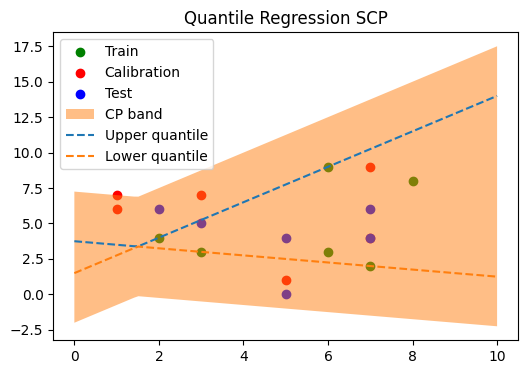

In [ ]:
# Reuse train / calibration / test from Section 4
X_train = train[:, 0].reshape(-1, 1)
Y_train = train[:, 1]

lower_q = alpha / 2          # 0.125
upper_q = 1 - alpha / 2      # 0.875

model_l = QuantileRegressor(quantile=lower_q, alpha=0)
model_u = QuantileRegressor(quantile=upper_q, alpha=0)
model_l.fit(X_train, Y_train)
model_u.fit(X_train, Y_train)

# ── Predictions on plot grid
y_l = model_l.predict(x_line)
y_u = model_u.predict(x_line)
upper = np.maximum(y_l, y_u)
lower = np.minimum(y_l, y_u)

# ── Calibration predictions
y_cal_l = model_l.predict(calibration[:, 0].reshape(-1, 1))
y_cal_u = model_u.predict(calibration[:, 0].reshape(-1, 1))
upper_cal = np.maximum(y_cal_l, y_cal_u)
lower_cal = np.minimum(y_cal_l, y_cal_u)

# ── Conformity scores: max(lower − y, y − upper)
res_l = (lower_cal - calibration[:, 1]).flatten()
res_u = (calibration[:, 1] - upper_cal).flatten()
residuals_q = [max(res_l[i], res_u[i]) for i in range(len(res_l))]
sorted_res_q = np.sort(residuals_q)

q_idx_q  = math.ceil((1 - alpha) * (len(sorted_res_q) + 1))
q_quant  = sorted_res_q[q_idx_q - 1]

print("Sorted quantile conformity scores:", sorted_res_q)
print("Quantile (correction):", q_quant)

# ── Plot
plt.figure(figsize=(6, 4))
plt.scatter(train[:, 0],       train[:, 1],       color="green", label="Train")
plt.scatter(calibration[:, 0], calibration[:, 1], color="red",   label="Calibration")
plt.scatter(test[:, 0],        test[:, 1],        color="blue",  label="Test")
plt.fill_between(x_line.flatten(),
                 upper.flatten() + q_quant,
                 lower.flatten() - q_quant,
                 alpha=0.5, color="C1", edgecolor="none", label="CP band")
plt.plot(x_line, upper, linestyle="--", label="Upper quantile")
plt.plot(x_line, lower, linestyle="--", label="Lower quantile")
plt.title("Quantile Regression SCP")
plt.legend()
plt.show()

## 6. Weighted SCP

Fit a secondary model that predicts the *magnitude* of residuals (heteroscedastic weights). Use those weights to normalize conformity scores, yielding an adaptive-width band.

Sorted weighted conformity scores: [0.04749745 0.20889488 0.93637532 1.42492339 1.56962025 2.36747529]
Quantile: 2.3674752920035935


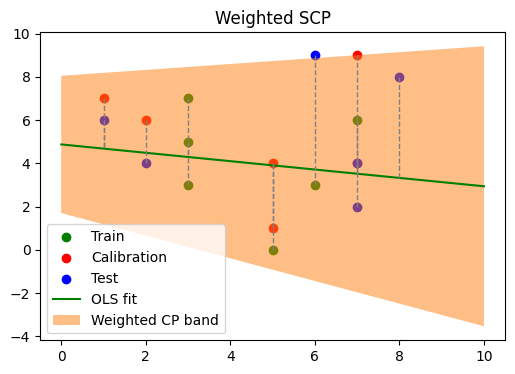

In [ ]:
np.random.seed(42)

full_dataset = np.vstack((dataset, new_points))
np.random.shuffle(full_dataset)
train, calibration, test = np.split(full_dataset, 3)

# ── Mean model (trained on train set)
mean_model   = LinearRegression()
weight_model = LinearRegression()

mean_scp_model = mean_model.fit(
    train[:, 0].reshape(-1, 1),
    train[:, 1].reshape(-1, 1)
)

y_fit_line = mean_scp_model.predict(x_line).flatten()
y_cal      = mean_scp_model.predict(calibration[:, 0].reshape(-1, 1)).flatten()
y_full     = mean_scp_model.predict(full_dataset[:, 0].reshape(-1, 1)).flatten()

# ── Train-set absolute residuals (used to fit the weight model)
y_train_pred       = mean_scp_model.predict(train[:, 0].reshape(-1, 1)).flatten()
abs_residuals_train = np.abs(train[:, 1] - y_train_pred)

# ── Weight model 
weight_scp_model = weight_model.fit(
    train[:, 0].reshape(-1, 1),
    abs_residuals_train.reshape(-1, 1)
)

weight_y_pred_cal = weight_scp_model.predict(
    calibration[:, 0].reshape(-1, 1)
).flatten()
weight_y_pred = weight_scp_model.predict(x_line).flatten()

# Guard against zero / negative weights
weight_y_pred_cal = np.maximum(weight_y_pred_cal, 1e-8)
weight_y_pred     = np.maximum(weight_y_pred, 1e-8)

# ── Calibration absolute residuals & weighted conformity scores
abs_residuals_cal = np.abs(calibration[:, 1] - y_cal)
sorted_res_w      = np.sort(abs_residuals_cal / weight_y_pred_cal)

alpha       = 0.25
q_idx_w     = math.ceil((1 - alpha) * (len(sorted_res_w) + 1))
q_idx_w     = min(q_idx_w, len(sorted_res_w))
q_weighted  = sorted_res_w[q_idx_w - 1]

print("Sorted weighted conformity scores:", sorted_res_w)
print("Quantile:", q_weighted)

# ── Plot
plt.figure(figsize=(6, 4))
plt.scatter(train[:, 0],       train[:, 1],       color="green", label="Train")
plt.scatter(calibration[:, 0], calibration[:, 1], color="red",   label="Calibration")
plt.scatter(test[:, 0],        test[:, 1],        color="blue",  label="Test")
plt.plot(x_line.flatten(), y_fit_line, color="green", label="OLS fit")
for i in range(len(full_dataset)):
    plt.plot([full_dataset[i][0], full_dataset[i][0]],
             [full_dataset[i][1], y_full[i]],
             linestyle="--", color="grey", linewidth=1)
plt.fill_between(
    x_line.flatten(),
    y_fit_line + q_weighted * weight_y_pred,
    y_fit_line - q_weighted * weight_y_pred,
    alpha=0.5, color="C1", edgecolor="none", label="Weighted CP band"
)
plt.title("Weighted SCP")
plt.legend()
plt.show()

## 7. Full Conformal Prediction (FCP) Regression

Unlike SCP, Full CP does not split the data. For every candidate point `(i, j)` in a 10×10 grid, it temporarily appends that point to the full dataset, refits the model, and checks whether the residual of `(i, j)` ranks within the `(1−α)` quantile of all residuals. Points that pass this test form the **conformal prediction set**.

**α = 0.25** → a point is included if its residual does not exceed the 75th percentile.

90 points in conformal prediction set


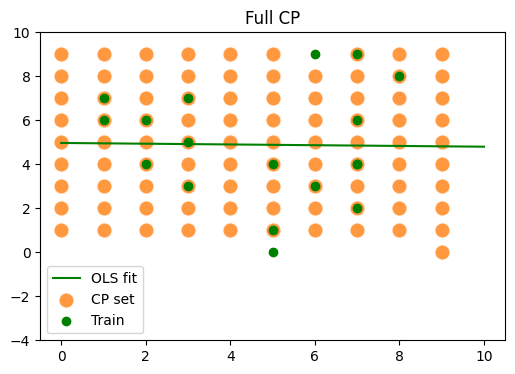

In [ ]:
np.random.seed(0)

set_y = []

# ── For each candidate point (i, j), test inclusion via Full CP
for i in range(10):
    for j in range(10):
        full_dataset = np.vstack((dataset, new_points, (i, j)))

        FCP_model = LinearRegression().fit(
            full_dataset[:, 0].reshape(-1, 1),
            full_dataset[:, 1].reshape(-1, 1)
        )

        y_FCP = FCP_model.predict(full_dataset[:, 0].reshape(-1, 1)).flatten()

        # ── Conformity scores (all points except the candidate)
        abs_res_cal    = np.abs(full_dataset[:-1, 1] - y_FCP[:-1])
        sorted_res_cal = np.sort(abs_res_cal)

        alpha = 0.25
        q_idx = math.ceil((1 - alpha) * (len(sorted_res_cal) + 1))
        q_scp = sorted_res_cal[q_idx - 1]

        # ── Include (i, j) if its residual is within the quantile
        y_hat = FCP_model.predict([[i]])[0][0]
        if abs(j - y_hat) <= q_scp:
            set_y.append([i, j])

print(f"{len(set_y)} points in conformal prediction set")

# ── Reference fit on the full training data (no candidate appended)
train_dataset   = np.vstack((dataset, new_points))
FCP_train_model = LinearRegression().fit(
    train_dataset[:, 0].reshape(-1, 1),
    train_dataset[:, 1].reshape(-1, 1)
)
y_fit_line = FCP_train_model.predict(x_line).flatten()

# ── Plot
set_y = np.array(set_y)

plt.figure(figsize=(6, 4))
plt.plot(x_line.flatten(), y_fit_line, color="green", label="OLS fit")
plt.scatter(set_y[:, 0], set_y[:, 1],
            color="C1", alpha=0.8, edgecolors="white", s=120, label="CP set")
plt.scatter(train_dataset[:, 0], train_dataset[:, 1],
            color="green", label="Train")
plt.title("Full CP")
plt.ylim(-4, 10)
plt.legend()
plt.show()